# **All in One Page**

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
all_cars = []

url = "https://www.pakwheels.com/used-cars/search/-/ct_karachi/"

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(url, headers=headers)
soup = BeautifulSoup(response.text, "html.parser")

ads = soup.select("div.well.search-list.ad-container")
for ad in ads:
    try:
        car_name = ad.select_one("a.car-name h3").text.strip()
        city = ad.select_one("ul.search-vehicle-info li").text.strip()
        price = ad.select_one("div.price-details").text.strip()

        detail_items = [li.text.strip() for li in ad.select("ul.search-vehicle-info-2 li")]
        details = " | ".join(detail_items)

        all_cars.append({
            "Car Name": car_name,
            "City": city,
            "Details": details,
            "Price": price,
        })

    except:
        pass

df = pd.DataFrame(all_cars)
# Split Details into separate columns
df[["Model Year", "Mileage", "Fuel Type", "Engine CC", "Transmission"]] = (
    df["Details"].str.split(" \| ", expand=True)
)

# Clean numeric fields
df["Mileage"] = df["Mileage"].str.replace(" km", "", regex=False)
df["Engine CC"] = df["Engine CC"].str.replace(" cc", "", regex=False)

df.to_csv("pak_cars_clean.csv", index=False)

print("Scraping Complete → pak_cars.csv generated!")



# **FULL DETAILED EXPLANATION (LINE BY LINE)**

Below is your code with *deep explanation* of every step.

---

## **1. Importing Required Libraries**

```python
import requests
from bs4 import BeautifulSoup
import pandas as pd
```

### **Explanation**

* `requests`
  Used to send an HTTP request to a webpage and get its HTML code.

* `BeautifulSoup`
  Used to parse (read + extract) the HTML code of the webpage.

* `pandas`
  Used to store data in table form (DataFrame) and later save it as CSV.

---

## **2. Empty List to Store All Cars**

```python
all_cars = []
```

### **Explanation**

* This empty list will store all scraped car dictionaries.
* Each car will be collected as a dictionary → appended to this list.

---

## **3. Target URL**

```python
url = "https://www.pakwheels.com/used-cars/search/-/ct_karachi/"
```

### **Explanation**

* This is the PakWheels page for **used cars in Karachi**.
* You are scraping all car ads from this URL.

---

## **4. Create Fake Browser Header**

```python
headers = {
    "User-Agent": "Mozilla/5.0"
}
```

### **Explanation**

* Websites sometimes block bots/scrapers.
* Adding a **User-Agent** makes your script look like a real browser.
* Prevents server from blocking your request.

---

## **5. Request the Web Page**

```python
response = requests.get(url, headers=headers)
```

### **Explanation**

* Sends an HTTP GET request to the URL.
* Returns the HTML of the webpage in `response`.

---

## **6. Parse the HTML**

```python
soup = BeautifulSoup(response.text, "html.parser")
```

### **Explanation**

* `response.text` → raw HTML code of the page.
* BeautifulSoup reads and structures this HTML.
* `"html.parser"` tells BeautifulSoup how to read HTML.

---

## **7. Select All Car Advertisement Blocks**

```python
ads = soup.select("div.well.search-list.ad-container")
```

### **Explanation**

* On PakWheels, each ad is inside a `<div>` containing these CSS classes:

  * `well`
  * `search-list`
  * `ad-container`
* `soup.select()` finds **all** HTML blocks matching this CSS pattern.
* `ads` becomes a list of all car ad HTML blocks.

---

## **8. Loop Through All Ads**

```python
for ad in ads:
```

### **Explanation**

* Iterates each advertisement block one by one.
* For each ad, extract:

  * car name
  * city
  * price
  * year / mileage / fuel / engine / transmission

---

## **9. Error Handling**

```python
    try:
```

### **Explanation**

* Some ads may be missing data.
* If any error occurs, skip the ad instead of stopping the whole program.

---

## **10. Extract Car Name**

```python
car_name = ad.select_one("a.car-name h3").text.strip()
```

### **Explanation**

* `select_one()` finds the first matching CSS selector.
* `a.car-name h3` is where the car name appears.
* `.text` extracts text only (not HTML).
* `.strip()` removes extra spaces or newline characters.

---

## **11. Extract City Name**

```python
city = ad.select_one("ul.search-vehicle-info li").text.strip()
```

### **Explanation**

* City name is inside the first `<li>` of the list `.search-vehicle-info`.
* Again `.text.strip()` cleans the extracted text.

---

## **12. Extract Price**

```python
price = ad.select_one("div.price-details").text.strip()
```

### **Explanation**

* Price is inside the `<div>` with class `price-details`.

---

## **13. Extract All Details (Year, km, Fuel, Engine, Transmission)**

```python
detail_items = [li.text.strip() for li in ad.select("ul.search-vehicle-info-2 li")]
```

### **Explanation**

* Loops through all `<li>` inside `.search-vehicle-info-2`.
* Extracts each detail:

  * Model year
  * Mileage
  * Fuel type
  * Engine CC
  * Transmission
* Stores them in a list.

---

## **14. Join Details Into One String**

```python
details = " | ".join(detail_items)
```

### **Explanation**

* Converts list → string with `" | "` separator.
* Example:
  `["2018", "52,000 km", "Petrol", "1500 cc", "Automatic"]`
  becomes
  `"2018 | 52,000 km | Petrol | 1500 cc | Automatic"`

---

## **15. Append Car Data Into List**

```python
all_cars.append({
    "Car Name": car_name,
    "City": city,
    "Details": details,
    "Price": price,
})
```

### **Explanation**

* Creates a dictionary for each car.
* Appends it to the `all_cars` list.
* This makes it easy to convert to a DataFrame later.

---

## **16. Skip Errors**

```python
    except:
        pass
```

### **Explanation**

* If any ad fails, ignore it and continue.
* Prevents script from stopping halfway.

---

## **17. Create Pandas DataFrame**

```python
df = pd.DataFrame(all_cars)
```

### **Explanation**

* Converts the list of dictionaries into a DataFrame (table).
* Each key becomes a column.

---

## **18. Split Details Into Multiple Columns**

```python
df[["Model Year", "Mileage", "Fuel Type", "Engine CC", "Transmission"]] = (
    df["Details"].str.split(" \| ", expand=True)
)
```

### **Explanation**

* The "Details" column is a single string like:

  ```
  2018 | 52,000 km | Petrol | 1500 cc | Automatic
  ```
* Splits this string into **5 separate columns**.
* `expand=True` → spread into new DataFrame columns.

---

## **19. Clean Mileage**

```python
df["Mileage"] = df["Mileage"].str.replace(" km", "", regex=False)
```

### **Explanation**

* Removes `" km"` from mileage values.
* Example:
  `"52,000 km"` → `"52,000"`

---

## **20. Clean Engine CC**

```python
df["Engine CC"] = df["Engine CC"].str.replace(" cc", "", regex=False)
```

### **Explanation**

* Removes `" cc"` from engine values.
* Example:
  `"1500 cc"` → `"1500"`

---

## **21. Save Clean CSV**

```python
df.to_csv("pak_cars_clean.csv", index=False)
```

### **Explanation**

* Saves the cleaned DataFrame into a CSV file.
* `index=False` removes default row numbers.

---

## **22. Save Raw CSV**

```python
df.to_csv("pak_cars.csv", index=False)
```

### **Explanation**

* Saves another CSV with same data (maybe raw version).
* You can remove one if not required.

---

## **23. Print Success Message**

```python
print("Scraping Complete → pak_cars.csv generated!")
```

### **Explanation**

* Confirms that your scraping process is done.

---



In [ ]:
import numpy as np
import pandas as pd


# Load your scraped data
df = pd.read_csv("pak_cars_50_pages.csv")

# -------------------------
# CLEAN MILEAGE
# -------------------------
df["Mileage"] = (
    df["Mileage"]
    .str.replace(",", "", regex=False)
    .str.replace(" km", "", regex=False)
    .replace("", np.nan)
    .astype(float)
)

# -------------------------
# CLEAN ENGINE CC
# -------------------------
df["Engine CC"] = (
    df["Engine CC"]
    .str.replace(",", "", regex=False)
    .str.replace(" cc", "", regex=False)
    .replace("", np.nan)
    .astype(float)
)

# -------------------------
# CLEAN PRICE
# -------------------------
def clean_price(p):
    if isinstance(p, str):
        p = p.replace("PKR", "").replace(",", "").strip()

        # Handle "lacs" / "lac" / "crore"
        if "lacs" in p or "lac" in p:
            num = float(p.split()[0])
            return int(num * 100000)  # convert to PKR

        if "crore" in p:
            num = float(p.split()[0])
            return int(num * 10000000)

        # If numeric PKR
        try:
            return int(p)
        except:
            return np.nan
    return np.nan

df["Price Clean"] = df["Price"].apply(clean_price)

# -------------------------
# NORMALIZE FUEL TYPE
# -------------------------
df["Fuel Type"] = (
    df["Fuel Type"]
    .str.strip()
    .str.title()
)

# -------------------------
# NORMALIZE TRANSMISSION
# -------------------------
df["Transmission"] = (
    df["Transmission"]
    .str.strip()
    .str.title()
)

# -------------------------
# REMOVE DUPLICATES
# -------------------------
df.drop_duplicates(subset=["Car Name", "Model Year", "Price Clean"], inplace=True)

# -------------------------
# DROP ROWS WITH NO PRICE
# -------------------------
df = df[df["Price Clean"].notna()]

# -------------------------
# Save Clean File
# -------------------------
df.to_csv("pak_cars_cleaned.csv", index=False)

print("✔ Data Cleaning Complete → pak_cars_cleaned.csv saved!")







In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time

all_cars = []
headers = {"User-Agent": "Mozilla/5.0"}

MAX_PAGES = 50

for page in range(1, MAX_PAGES + 1):
    print(f"Scraping page {page}...")

    url = f"https://www.pakwheels.com/used-cars/search/-/ct_karachi/?page={page}"
    response = requests.get(url, headers=headers)
    soup = BeautifulSoup(response.text, "html.parser")

    ads = soup.select("div.well.search-list.ad-container")

    if len(ads) == 0:
        print("No more ads found. Stopping...")
        break

    for ad in ads:
        try:
            car_name = ad.select_one("a.car-name h3").text.strip()
            city = ad.select_one("ul.search-vehicle-info li").text.strip()
            price = ad.select_one("div.price-details").text.strip()

            detail_items = [li.text.strip() for li in ad.select("ul.search-vehicle-info-2 li")]
            details = " | ".join(detail_items)

            all_cars.append({
                "Car Name": car_name,
                "City": city,
                "Details": details,
                "Price": price,
            })

        except:
            pass

    time.sleep(1)


df = pd.DataFrame(all_cars)

details_split = df["Details"].str.split(r"\s*\|\s*", expand=True).reindex(columns=range(5)).fillna("")

df[["Model Year", "Mileage", "Fuel Type", "Engine CC", "Transmission"]] = details_split

df.drop("Details", axis="columns", inplace = True)

df.to_csv("pak_cars_50_pages.csv", index=False)

print("Scraping Completed → pak_cars_50_pages.csv generated!")

In [1]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.2.5-py3-none-any.whl.metadata (5.0 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.1 MB 2.8 MB/s eta 0:00:03
   ----- ---------------------------------- 1.0/8.1 MB 2.5 MB/s eta 0:00:03
   ----- ---------------------------------- 1.0/8.1 MB 2.5 MB/s eta 0:00:03
   ----- ---------------------------------- 1.0/8.1 MB 2.5 MB/s eta 0:00:03
   ---------- ----------------------------- 2.1/8.1 MB 2.0 MB/s eta 0:00:04
   ---------- ----------------------------- 2.1/8.1 MB 2.0 MB/s eta 0:00:04
   ------------ --------------------------- 2.6/8.1 MB 1.7 MB/s eta 0:00:04
   -------------- ------------------------- 2.9/8.1 MB 1.7 MB/s eta 0:00:04
   -------------- ------------------------- 2.9/8.1 MB 1.7 MB/s eta 0:00:04
   ------------------- -------------------- 3.9/

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import streamlit as st

In [2]:
all_cars = []

In [3]:
headers = {"User-Agent": "Mozilla/5.0"}

In [4]:
MAX_PAGES = 5

In [5]:
for page in range(1, MAX_PAGES + 1):
    print(f"Scraping page {page}...")

    url = f"https://www.pakwheels.com/used-cars/search/-/ct_karachi/?page={page}"
    response = requests.get(url, headers=headers)
    soup = BeautifulSoup(response.text, "html.parser")

    ads = soup.select("div.well.search-list.ad-container")

    if len(ads) == 0:
        print("No more ads found. Stopping...")
        break

    for ad in ads:
        try:
            car_name = ad.select_one("a.car-name h3").text.strip()
            city = ad.select_one("ul.search-vehicle-info li").text.strip()
            price = ad.select_one("div.price-details").text.strip()

            detail_items = [li.text.strip() for li in ad.select("ul.search-vehicle-info-2 li")]
            details = " | ".join(detail_items)

            all_cars.append({
                "Car Name": car_name,
                "City": city,
                "Details": details,
                "Price (PKR)": price,
            })

        except:
            pass

    time.sleep(1)


Scraping page 1...
Scraping page 2...
Scraping page 3...
Scraping page 4...
Scraping page 5...


In [6]:
ads

[<div class="well search-list clearfix ad-container page-5 pos-rel">
 <div class="col-md-3 grid-style">
 <div class="img-box">
 <div id="gallery-10856774">
 <div class="custom-html" id="contact-user-info-10856774" style="display: none">
 <div class="light-gallery-user-info clearfix">
 <button class="btn btn-secondary pull-right ml10" data-ad-featured="true" data-ad-id="12130121" data-ad-title="Toyota Raize 2020 for sale in Karachi" data-ad-type="UsedCar" onclick="$('#lg-close').click();showMessagePopup(this); trackGA4Events('chat', 'used_car', 'Toyota', 'Raize', 'Z', 'false', 'Karachi');">
                                 Send Message
                       </button>
 <button class="btn btn-success phone_number_btn ad-show-btn pull-right" data-ad-id="10856774" data-price="6175000" onclick='handle_phone_click_on_gallery(
                                 "#gallery-10856774",
                                 "/used-cars/10856774/increment_phone_count?sid=30a4dc1e6e6173869c71c524a1a4d4b7",

In [7]:
ad

<div class="well search-list clearfix ad-container page-5 pos-rel">
<div class="col-md-3 grid-style">
<div class="img-box">
<div id="gallery-10856668">
<div class="custom-html" id="contact-user-info-10856668" style="display: none">
<div class="light-gallery-user-info clearfix">
<button class="btn btn-secondary pull-right ml10" data-ad-featured="true" data-ad-id="12129999" data-ad-title="Toyota Corolla 2019 for sale in Karachi" data-ad-type="UsedCar" onclick="$('#lg-close').click();showMessagePopup(this); trackGA4Events('chat', 'used_car', 'Toyota', 'Corolla', 'XLi VVTi', 'false', 'Karachi');">
                                Send Message
                      </button>
<button class="btn btn-success phone_number_btn ad-show-btn pull-right" data-ad-id="10856668" data-price="3900000" onclick='handle_phone_click_on_gallery(
                                "#gallery-10856668",
                                "/used-cars/10856668/increment_phone_count?sid=30a4dc1e6e6173869c71c524a1a4d4b7",


In [8]:
type(ads)

bs4.element.ResultSet

In [9]:
type(ad)

bs4.element.Tag

In [10]:
all_cars

[{'Car Name': 'Daihatsu Mira  2023 X SA lll for Sale',
  'City': 'Karachi',
  'Details': '2023 | 8,500 km | Petrol | 660 cc | Automatic | 4.5 Grade',
  'Price (PKR)': 'PKR 40.5 lacs'},
 {'Car Name': 'Honda Civic 11th Generation 2022 Oriel for Sale',
  'City': 'Karachi',
  'Details': '2022 | 16,000 km | Petrol | 1500 cc | Automatic',
  'Price (PKR)': 'PKR 77 lacs'},
 {'Car Name': 'Honda City 5th (GM2) Generation 2019 1.3 i-VTEC Prosmatec for Sale',
  'City': 'Karachi',
  'Details': '2019 | 95,043 km | Petrol | 1300 cc | Automatic',
  'Price (PKR)': 'PKR 38 lacs'},
 {'Car Name': 'Daihatsu Hijet  2013  for Sale',
  'City': 'Karachi',
  'Details': '2013 | 255,196 km | Petrol | 660 cc | Automatic | 4 Grade',
  'Price (PKR)': 'PKR 16 lacs'},
 {'Car Name': 'Suzuki Alto  2021 VXL AGS for Sale',
  'City': 'Karachi',
  'Details': '2021 | 73,000 km | Petrol | 660 cc | Automatic',
  'Price (PKR)': 'PKR 25.5 lacs'},
 {'Car Name': 'Suzuki Alto  2022 VXL AGS for Sale',
  'City': 'Karachi',
  'Details

In [11]:
type(all_cars)

list

In [12]:
df = pd.DataFrame(all_cars)

In [13]:
df

,Car Name,City,Details,Price (PKR)
0,Daihatsu Mira 2023 X SA lll for Sale,Karachi,"2023 | 8,500 km | Petrol | 660 cc | Automatic ...",PKR 40.5 lacs
1,Honda Civic 11th Generation 2022 Oriel for Sale,Karachi,"2022 | 16,000 km | Petrol | 1500 cc | Automatic",PKR 77 lacs
2,Honda City 5th (GM2) Generation 2019 1.3 i-VTE...,Karachi,"2019 | 95,043 km | Petrol | 1300 cc | Automatic",PKR 38 lacs
3,Daihatsu Hijet 2013 for Sale,Karachi,"2013 | 255,196 km | Petrol | 660 cc | Automati...",PKR 16 lacs
4,Suzuki Alto 2021 VXL AGS for Sale,Karachi,"2021 | 73,000 km | Petrol | 660 cc | Automatic",PKR 25.5 lacs
...,...,...,...,...
148,Toyota Corolla Axio 2017 WXB for Sale,Karachi,"2017 | 122,604 km | Petrol | 1500 cc | Automat...",PKR 60 lacs
149,Toyota Fortuner 2017 2.7 VVTi for Sale,Karachi,"2017 | 108,621 km | Petrol | 2700 cc | Automatic",PKR 1.03 crore
150,Toyota Prado 3rd (J120) Generation 2004 TZ 4.0...,Karachi,"2004 | 20,000 km | Petrol | 4000 cc | Automatic",PKR 85 lacs
151,Toyota Hilux 2021 4x4 Single Cab Standard 2.8...,Karachi,"2021 | 90,000 km | Diesel | 2800 cc | Manual",PKR 1.19 crore


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Car Name     153 non-null    object
 1   City         153 non-null    object
 2   Details      153 non-null    object
 3   Price (PKR)  153 non-null    object
dtypes: object(4)
memory usage: 4.9+ KB


In [15]:
details_split = df["Details"].str.split(r"\s*\|\s*", expand=True).reindex(columns=range(5)).fillna("")
df[["Model Year", "Mileage (km)", "Fuel Type", "Engine CC", "Transmission"]] = details_split

In [16]:
df

,Car Name,City,Details,Price (PKR),Model Year,Mileage (km),Fuel Type,Engine CC,Transmission
0,Daihatsu Mira 2023 X SA lll for Sale,Karachi,"2023 | 8,500 km | Petrol | 660 cc | Automatic ...",PKR 40.5 lacs,2023,"8,500 km",Petrol,660 cc,Automatic
1,Honda Civic 11th Generation 2022 Oriel for Sale,Karachi,"2022 | 16,000 km | Petrol | 1500 cc | Automatic",PKR 77 lacs,2022,"16,000 km",Petrol,1500 cc,Automatic
2,Honda City 5th (GM2) Generation 2019 1.3 i-VTE...,Karachi,"2019 | 95,043 km | Petrol | 1300 cc | Automatic",PKR 38 lacs,2019,"95,043 km",Petrol,1300 cc,Automatic
3,Daihatsu Hijet 2013 for Sale,Karachi,"2013 | 255,196 km | Petrol | 660 cc | Automati...",PKR 16 lacs,2013,"255,196 km",Petrol,660 cc,Automatic
4,Suzuki Alto 2021 VXL AGS for Sale,Karachi,"2021 | 73,000 km | Petrol | 660 cc | Automatic",PKR 25.5 lacs,2021,"73,000 km",Petrol,660 cc,Automatic
...,...,...,...,...,...,...,...,...,...
148,Toyota Corolla Axio 2017 WXB for Sale,Karachi,"2017 | 122,604 km | Petrol | 1500 cc | Automat...",PKR 60 lacs,2017,"122,604 km",Petrol,1500 cc,Automatic
149,Toyota Fortuner 2017 2.7 VVTi for Sale,Karachi,"2017 | 108,621 km | Petrol | 2700 cc | Automatic",PKR 1.03 crore,2017,"108,621 km",Petrol,2700 cc,Automatic
150,Toyota Prado 3rd (J120) Generation 2004 TZ 4.0...,Karachi,"2004 | 20,000 km | Petrol | 4000 cc | Automatic",PKR 85 lacs,2004,"20,000 km",Petrol,4000 cc,Automatic
151,Toyota Hilux 2021 4x4 Single Cab Standard 2.8...,Karachi,"2021 | 90,000 km | Diesel | 2800 cc | Manual",PKR 1.19 crore,2021,"90,000 km",Diesel,2800 cc,Manual


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Car Name      153 non-null    object
 1   City          153 non-null    object
 2   Details       153 non-null    object
 3   Price (PKR)   153 non-null    object
 4   Model Year    153 non-null    object
 5   Mileage (km)  153 non-null    object
 6   Fuel Type     153 non-null    object
 7   Engine CC     153 non-null    object
 8   Transmission  153 non-null    object
dtypes: object(9)
memory usage: 10.9+ KB


In [18]:
df.drop("Details", axis="columns", inplace = True)

In [19]:
df

,Car Name,City,Price (PKR),Model Year,Mileage (km),Fuel Type,Engine CC,Transmission
0,Daihatsu Mira 2023 X SA lll for Sale,Karachi,PKR 40.5 lacs,2023,"8,500 km",Petrol,660 cc,Automatic
1,Honda Civic 11th Generation 2022 Oriel for Sale,Karachi,PKR 77 lacs,2022,"16,000 km",Petrol,1500 cc,Automatic
2,Honda City 5th (GM2) Generation 2019 1.3 i-VTE...,Karachi,PKR 38 lacs,2019,"95,043 km",Petrol,1300 cc,Automatic
3,Daihatsu Hijet 2013 for Sale,Karachi,PKR 16 lacs,2013,"255,196 km",Petrol,660 cc,Automatic
4,Suzuki Alto 2021 VXL AGS for Sale,Karachi,PKR 25.5 lacs,2021,"73,000 km",Petrol,660 cc,Automatic
...,...,...,...,...,...,...,...,...
148,Toyota Corolla Axio 2017 WXB for Sale,Karachi,PKR 60 lacs,2017,"122,604 km",Petrol,1500 cc,Automatic
149,Toyota Fortuner 2017 2.7 VVTi for Sale,Karachi,PKR 1.03 crore,2017,"108,621 km",Petrol,2700 cc,Automatic
150,Toyota Prado 3rd (J120) Generation 2004 TZ 4.0...,Karachi,PKR 85 lacs,2004,"20,000 km",Petrol,4000 cc,Automatic
151,Toyota Hilux 2021 4x4 Single Cab Standard 2.8...,Karachi,PKR 1.19 crore,2021,"90,000 km",Diesel,2800 cc,Manual


In [20]:
import numpy as np

In [21]:
# CLEAN MILEAGE

df["Mileage (km)"] = (
    df["Mileage (km)"]
    .str.replace(",", "", regex=False)
    .str.replace(" km", "", regex=False)
    .replace("", np.nan)
    .astype(float)
)

In [22]:
df

,Car Name,City,Price (PKR),Model Year,Mileage (km),Fuel Type,Engine CC,Transmission
0,Daihatsu Mira 2023 X SA lll for Sale,Karachi,PKR 40.5 lacs,2023,8500.0,Petrol,660 cc,Automatic
1,Honda Civic 11th Generation 2022 Oriel for Sale,Karachi,PKR 77 lacs,2022,16000.0,Petrol,1500 cc,Automatic
2,Honda City 5th (GM2) Generation 2019 1.3 i-VTE...,Karachi,PKR 38 lacs,2019,95043.0,Petrol,1300 cc,Automatic
3,Daihatsu Hijet 2013 for Sale,Karachi,PKR 16 lacs,2013,255196.0,Petrol,660 cc,Automatic
4,Suzuki Alto 2021 VXL AGS for Sale,Karachi,PKR 25.5 lacs,2021,73000.0,Petrol,660 cc,Automatic
...,...,...,...,...,...,...,...,...
148,Toyota Corolla Axio 2017 WXB for Sale,Karachi,PKR 60 lacs,2017,122604.0,Petrol,1500 cc,Automatic
149,Toyota Fortuner 2017 2.7 VVTi for Sale,Karachi,PKR 1.03 crore,2017,108621.0,Petrol,2700 cc,Automatic
150,Toyota Prado 3rd (J120) Generation 2004 TZ 4.0...,Karachi,PKR 85 lacs,2004,20000.0,Petrol,4000 cc,Automatic
151,Toyota Hilux 2021 4x4 Single Cab Standard 2.8...,Karachi,PKR 1.19 crore,2021,90000.0,Diesel,2800 cc,Manual


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car Name      153 non-null    object 
 1   City          153 non-null    object 
 2   Price (PKR)   153 non-null    object 
 3   Model Year    153 non-null    object 
 4   Mileage (km)  153 non-null    float64
 5   Fuel Type     153 non-null    object 
 6   Engine CC     153 non-null    object 
 7   Transmission  153 non-null    object 
dtypes: float64(1), object(7)
memory usage: 9.7+ KB


In [24]:
# CLEAN PRICE

def clean_price(p):
    if isinstance(p, str):
        p = p.replace("PKR", "").replace(",", "").strip()

        # Handle "lacs" / "lac" / "crore"
        
        if "lacs" in p or "lac" in p:
            num = float(p.split()[0])
            return int(num * 100000)  # convert to PKR

        if "crore" in p:
            num = float(p.split()[0])
            return int(num * 10000000)

        # If numeric PKR
        try:
            return int(p)
        except:
            return np.nan
    return np.nan

In [25]:
df["Price (PKR)"] = df["Price (PKR)"].apply(clean_price)

In [26]:
df

,Car Name,City,Price (PKR),Model Year,Mileage (km),Fuel Type,Engine CC,Transmission
0,Daihatsu Mira 2023 X SA lll for Sale,Karachi,4050000.0,2023,8500.0,Petrol,660 cc,Automatic
1,Honda Civic 11th Generation 2022 Oriel for Sale,Karachi,7700000.0,2022,16000.0,Petrol,1500 cc,Automatic
2,Honda City 5th (GM2) Generation 2019 1.3 i-VTE...,Karachi,3800000.0,2019,95043.0,Petrol,1300 cc,Automatic
3,Daihatsu Hijet 2013 for Sale,Karachi,1600000.0,2013,255196.0,Petrol,660 cc,Automatic
4,Suzuki Alto 2021 VXL AGS for Sale,Karachi,2550000.0,2021,73000.0,Petrol,660 cc,Automatic
...,...,...,...,...,...,...,...,...
148,Toyota Corolla Axio 2017 WXB for Sale,Karachi,6000000.0,2017,122604.0,Petrol,1500 cc,Automatic
149,Toyota Fortuner 2017 2.7 VVTi for Sale,Karachi,10300000.0,2017,108621.0,Petrol,2700 cc,Automatic
150,Toyota Prado 3rd (J120) Generation 2004 TZ 4.0...,Karachi,8500000.0,2004,20000.0,Petrol,4000 cc,Automatic
151,Toyota Hilux 2021 4x4 Single Cab Standard 2.8...,Karachi,11900000.0,2021,90000.0,Diesel,2800 cc,Manual


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car Name      153 non-null    object 
 1   City          153 non-null    object 
 2   Price (PKR)   150 non-null    float64
 3   Model Year    153 non-null    object 
 4   Mileage (km)  153 non-null    float64
 5   Fuel Type     153 non-null    object 
 6   Engine CC     153 non-null    object 
 7   Transmission  153 non-null    object 
dtypes: float64(2), object(6)
memory usage: 9.7+ KB


In [28]:
df.dropna()

,Car Name,City,Price (PKR),Model Year,Mileage (km),Fuel Type,Engine CC,Transmission
0,Daihatsu Mira 2023 X SA lll for Sale,Karachi,4050000.0,2023,8500.0,Petrol,660 cc,Automatic
1,Honda Civic 11th Generation 2022 Oriel for Sale,Karachi,7700000.0,2022,16000.0,Petrol,1500 cc,Automatic
2,Honda City 5th (GM2) Generation 2019 1.3 i-VTE...,Karachi,3800000.0,2019,95043.0,Petrol,1300 cc,Automatic
3,Daihatsu Hijet 2013 for Sale,Karachi,1600000.0,2013,255196.0,Petrol,660 cc,Automatic
4,Suzuki Alto 2021 VXL AGS for Sale,Karachi,2550000.0,2021,73000.0,Petrol,660 cc,Automatic
...,...,...,...,...,...,...,...,...
148,Toyota Corolla Axio 2017 WXB for Sale,Karachi,6000000.0,2017,122604.0,Petrol,1500 cc,Automatic
149,Toyota Fortuner 2017 2.7 VVTi for Sale,Karachi,10300000.0,2017,108621.0,Petrol,2700 cc,Automatic
150,Toyota Prado 3rd (J120) Generation 2004 TZ 4.0...,Karachi,8500000.0,2004,20000.0,Petrol,4000 cc,Automatic
151,Toyota Hilux 2021 4x4 Single Cab Standard 2.8...,Karachi,11900000.0,2021,90000.0,Diesel,2800 cc,Manual


In [29]:
df = df.dropna()

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150 entries, 0 to 152
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car Name      150 non-null    object 
 1   City          150 non-null    object 
 2   Price (PKR)   150 non-null    float64
 3   Model Year    150 non-null    object 
 4   Mileage (km)  150 non-null    float64
 5   Fuel Type     150 non-null    object 
 6   Engine CC     150 non-null    object 
 7   Transmission  150 non-null    object 
dtypes: float64(2), object(6)
memory usage: 10.5+ KB


In [31]:
df

,Car Name,City,Price (PKR),Model Year,Mileage (km),Fuel Type,Engine CC,Transmission
0,Daihatsu Mira 2023 X SA lll for Sale,Karachi,4050000.0,2023,8500.0,Petrol,660 cc,Automatic
1,Honda Civic 11th Generation 2022 Oriel for Sale,Karachi,7700000.0,2022,16000.0,Petrol,1500 cc,Automatic
2,Honda City 5th (GM2) Generation 2019 1.3 i-VTE...,Karachi,3800000.0,2019,95043.0,Petrol,1300 cc,Automatic
3,Daihatsu Hijet 2013 for Sale,Karachi,1600000.0,2013,255196.0,Petrol,660 cc,Automatic
4,Suzuki Alto 2021 VXL AGS for Sale,Karachi,2550000.0,2021,73000.0,Petrol,660 cc,Automatic
...,...,...,...,...,...,...,...,...
148,Toyota Corolla Axio 2017 WXB for Sale,Karachi,6000000.0,2017,122604.0,Petrol,1500 cc,Automatic
149,Toyota Fortuner 2017 2.7 VVTi for Sale,Karachi,10300000.0,2017,108621.0,Petrol,2700 cc,Automatic
150,Toyota Prado 3rd (J120) Generation 2004 TZ 4.0...,Karachi,8500000.0,2004,20000.0,Petrol,4000 cc,Automatic
151,Toyota Hilux 2021 4x4 Single Cab Standard 2.8...,Karachi,11900000.0,2021,90000.0,Diesel,2800 cc,Manual


In [32]:
df.isnull().sum()

Car Name        0
City            0
Price (PKR)     0
Model Year      0
Mileage (km)    0
Fuel Type       0
Engine CC       0
Transmission    0
dtype: int64

In [33]:
df.duplicated().sum()

np.int64(29)

In [34]:
df[df.duplicated()]

,Car Name,City,Price (PKR),Model Year,Mileage (km),Fuel Type,Engine CC,Transmission
25,Honda City 2006 i-DSI Vario for Sale,Karachi,1850000.0,2006,192000.0,Petrol,1300 cc,Automatic
26,Toyota Corolla 2019 Altis Automatic 1.6 for Sale,Karachi,4600000.0,2019,85140.0,Petrol,1600 cc,Automatic
52,Suzuki Alto 2025 VXL AGS Upgraded for Sale,Karachi,3350000.0,2025,4072.0,Petrol,660 cc,Automatic
53,Toyota Raize 2021 Z for Sale,Karachi,6600000.0,2021,28261.0,Petrol,1000 cc,Automatic
54,Toyota Raize 2021 Z for Sale,Karachi,6900000.0,2021,32000.0,Petrol,1000 cc,Automatic
55,Suzuki Swift 2017 DLX Automatic 1.3 for Sale,Karachi,2600000.0,2017,62000.0,Petrol,1300 cc,Automatic
56,Toyota Raize 2020 Z for Sale,Karachi,6150000.0,2020,40000.0,Petrol,1000 cc,Automatic
57,Toyota Raize 2020 Z for Sale,Karachi,5750000.0,2020,35000.0,Petrol,1000 cc,Automatic
58,Suzuki Swift 2016 DLX 1.3 for Sale,Karachi,2150000.0,2016,225878.0,Petrol,1300 cc,Manual
59,Toyota Raize 2020 G for Sale,Karachi,5750000.0,2020,38000.0,Petrol,1000 cc,Automatic


In [35]:
df.drop_duplicates(inplace=True)

C:\Users\STARIZ.PK\AppData\Local\Temp\ipykernel_9952\3006716147.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(inplace=True)


In [36]:
df

,Car Name,City,Price (PKR),Model Year,Mileage (km),Fuel Type,Engine CC,Transmission
0,Daihatsu Mira 2023 X SA lll for Sale,Karachi,4050000.0,2023,8500.0,Petrol,660 cc,Automatic
1,Honda Civic 11th Generation 2022 Oriel for Sale,Karachi,7700000.0,2022,16000.0,Petrol,1500 cc,Automatic
2,Honda City 5th (GM2) Generation 2019 1.3 i-VTE...,Karachi,3800000.0,2019,95043.0,Petrol,1300 cc,Automatic
3,Daihatsu Hijet 2013 for Sale,Karachi,1600000.0,2013,255196.0,Petrol,660 cc,Automatic
4,Suzuki Alto 2021 VXL AGS for Sale,Karachi,2550000.0,2021,73000.0,Petrol,660 cc,Automatic
...,...,...,...,...,...,...,...,...
148,Toyota Corolla Axio 2017 WXB for Sale,Karachi,6000000.0,2017,122604.0,Petrol,1500 cc,Automatic
149,Toyota Fortuner 2017 2.7 VVTi for Sale,Karachi,10300000.0,2017,108621.0,Petrol,2700 cc,Automatic
150,Toyota Prado 3rd (J120) Generation 2004 TZ 4.0...,Karachi,8500000.0,2004,20000.0,Petrol,4000 cc,Automatic
151,Toyota Hilux 2021 4x4 Single Cab Standard 2.8...,Karachi,11900000.0,2021,90000.0,Diesel,2800 cc,Manual


In [37]:
df.duplicated().sum()

np.int64(0)

In [38]:
df["Car Name"] = (
    df["Car Name"]
    .str.replace(r"\s*for sale\s*$", "", case=False, regex=True)
    .str.strip()
)

C:\Users\STARIZ.PK\AppData\Local\Temp\ipykernel_9952\3147283156.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Car Name"] = (


In [39]:
df

,Car Name,City,Price (PKR),Model Year,Mileage (km),Fuel Type,Engine CC,Transmission
0,Daihatsu Mira 2023 X SA lll,Karachi,4050000.0,2023,8500.0,Petrol,660 cc,Automatic
1,Honda Civic 11th Generation 2022 Oriel,Karachi,7700000.0,2022,16000.0,Petrol,1500 cc,Automatic
2,Honda City 5th (GM2) Generation 2019 1.3 i-VTE...,Karachi,3800000.0,2019,95043.0,Petrol,1300 cc,Automatic
3,Daihatsu Hijet 2013,Karachi,1600000.0,2013,255196.0,Petrol,660 cc,Automatic
4,Suzuki Alto 2021 VXL AGS,Karachi,2550000.0,2021,73000.0,Petrol,660 cc,Automatic
...,...,...,...,...,...,...,...,...
148,Toyota Corolla Axio 2017 WXB,Karachi,6000000.0,2017,122604.0,Petrol,1500 cc,Automatic
149,Toyota Fortuner 2017 2.7 VVTi,Karachi,10300000.0,2017,108621.0,Petrol,2700 cc,Automatic
150,Toyota Prado 3rd (J120) Generation 2004 TZ 4.0,Karachi,8500000.0,2004,20000.0,Petrol,4000 cc,Automatic
151,Toyota Hilux 2021 4x4 Single Cab Standard 2.8,Karachi,11900000.0,2021,90000.0,Diesel,2800 cc,Manual


In [40]:
df["Car Name"] = (
    df["Car Name"]
    .str.replace(r"\b(19[7-9][0-9]|20[0-2][0-9])\b", "", regex=True)
    .str.replace(r"\s+", " ", regex=True)  # fix double spaces
    .str.strip()
)

C:\Users\STARIZ.PK\AppData\Local\Temp\ipykernel_9952\1325507251.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Car Name"] = (


In [41]:
df

,Car Name,City,Price (PKR),Model Year,Mileage (km),Fuel Type,Engine CC,Transmission
0,Daihatsu Mira X SA lll,Karachi,4050000.0,2023,8500.0,Petrol,660 cc,Automatic
1,Honda Civic 11th Generation Oriel,Karachi,7700000.0,2022,16000.0,Petrol,1500 cc,Automatic
2,Honda City 5th (GM2) Generation 1.3 i-VTEC Pro...,Karachi,3800000.0,2019,95043.0,Petrol,1300 cc,Automatic
3,Daihatsu Hijet,Karachi,1600000.0,2013,255196.0,Petrol,660 cc,Automatic
4,Suzuki Alto VXL AGS,Karachi,2550000.0,2021,73000.0,Petrol,660 cc,Automatic
...,...,...,...,...,...,...,...,...
148,Toyota Corolla Axio WXB,Karachi,6000000.0,2017,122604.0,Petrol,1500 cc,Automatic
149,Toyota Fortuner 2.7 VVTi,Karachi,10300000.0,2017,108621.0,Petrol,2700 cc,Automatic
150,Toyota Prado 3rd (J120) Generation TZ 4.0,Karachi,8500000.0,2004,20000.0,Petrol,4000 cc,Automatic
151,Toyota Hilux 4x4 Single Cab Standard 2.8,Karachi,11900000.0,2021,90000.0,Diesel,2800 cc,Manual


In [42]:
df = df.reset_index(drop=True)

In [43]:
df

,Car Name,City,Price (PKR),Model Year,Mileage (km),Fuel Type,Engine CC,Transmission
0,Daihatsu Mira X SA lll,Karachi,4050000.0,2023,8500.0,Petrol,660 cc,Automatic
1,Honda Civic 11th Generation Oriel,Karachi,7700000.0,2022,16000.0,Petrol,1500 cc,Automatic
2,Honda City 5th (GM2) Generation 1.3 i-VTEC Pro...,Karachi,3800000.0,2019,95043.0,Petrol,1300 cc,Automatic
3,Daihatsu Hijet,Karachi,1600000.0,2013,255196.0,Petrol,660 cc,Automatic
4,Suzuki Alto VXL AGS,Karachi,2550000.0,2021,73000.0,Petrol,660 cc,Automatic
...,...,...,...,...,...,...,...,...
116,Toyota Corolla Axio WXB,Karachi,6000000.0,2017,122604.0,Petrol,1500 cc,Automatic
117,Toyota Fortuner 2.7 VVTi,Karachi,10300000.0,2017,108621.0,Petrol,2700 cc,Automatic
118,Toyota Prado 3rd (J120) Generation TZ 4.0,Karachi,8500000.0,2004,20000.0,Petrol,4000 cc,Automatic
119,Toyota Hilux 4x4 Single Cab Standard 2.8,Karachi,11900000.0,2021,90000.0,Diesel,2800 cc,Manual


In [44]:
st.title("Car Data & Visualization")
st.subheader("DataFrame")
st.dataframe(df)

2025-11-22 15:54:42.052 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-22 15:54:42.422 
  command:

    streamlit run C:\Users\STARIZ.PK\anaconda3\envs\py312\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2025-11-22 15:54:42.423 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-22 15:54:42.424 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-22 15:54:42.425 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-22 15:54:42.426 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-22 15:54:42.426 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-22 15:54:42.435 Thread '

DeltaGenerator()

In [49]:
df.to_csv("Pak_Wheels_Karachi.csv", index=False)

In [55]:
df['Engine CC'].unique()

array(['660 cc', '1500 cc', '2400 cc', '1300 cc', '1000 cc', '1800 cc',
       '800 cc', '1490 cc', '1600 cc', '996 cc', '2000 cc', '2700 cc',
       '1200 cc', '5500 cc', '3000 cc', '658 cc', '1598 cc', '2500 cc',
       '1400 cc', '5700 cc', '2800 cc', '3400 cc', '3500 cc', '4000 cc',
       '4600 cc', '6203 cc', '3200 cc', '71.0 kWh', '3600 cc', '1198 cc',
       '2200 cc', '55.0 kWh', '4400 cc', '60.0 kWh', '49.0 kWh', '796 cc',
       '40.0 kWh', '7100.0 kWh', '1323 cc', '1299 cc', '4608 cc',
       '2398 cc', '3299 cc', '896 cc', '105.0 kWh', '181.0 kWh',
       '1497 cc'], dtype=object)

ValueError: x and y must be the same size

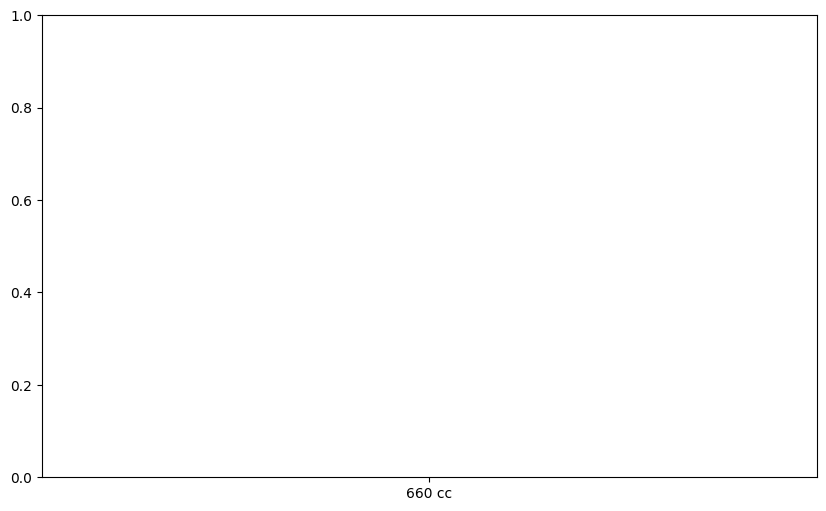

In [71]:
# --------------------------------------------------
# 1) Price vs Engine CC (Scatter Plot)
# --------------------------------------------------
plt.figure(figsize=(10,6))
plt.scatter(df['Engine CC'].unique(), df["Price (PKR)"])
plt.xlabel("Engine CC")
plt.ylabel("Price (PKR)")
plt.title("Price vs Engine CC")
plt.show()

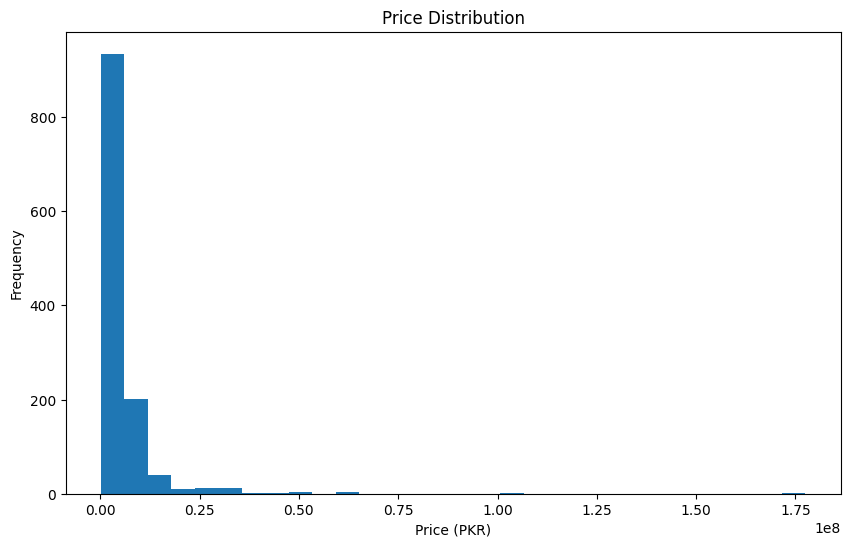

In [72]:
# --------------------------------------------------
# 2) Price Distribution (Histogram)
# --------------------------------------------------
plt.figure(figsize=(10,6))
plt.hist(df["Price (PKR)"], bins=30)
plt.xlabel("Price (PKR)")
plt.ylabel("Frequency")
plt.title("Price Distribution")
plt.show()

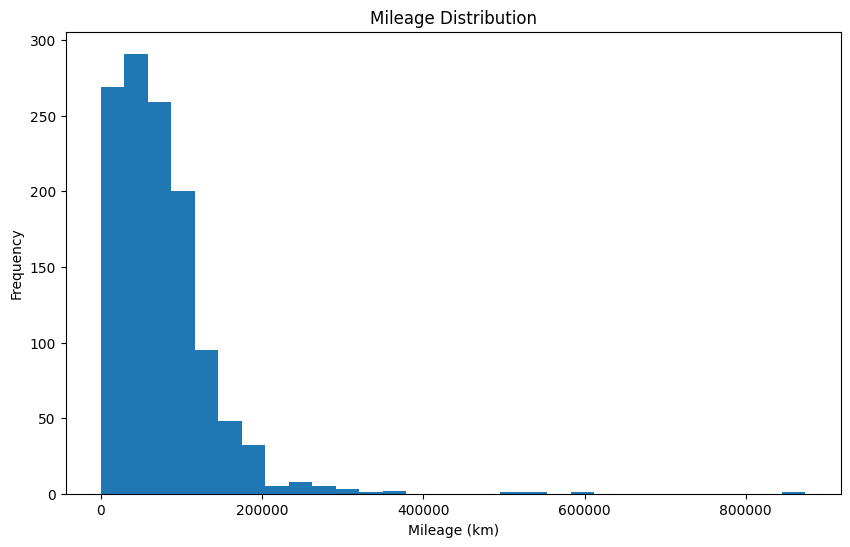

In [75]:
# --------------------------------------------------
# 3) Mileage Distribution (Histogram)
# --------------------------------------------------
plt.figure(figsize=(10,6))
plt.hist(df["Mileage (km)"], bins=30)
plt.xlabel("Mileage (km)")
plt.ylabel("Frequency")
plt.title("Mileage Distribution")
plt.show()

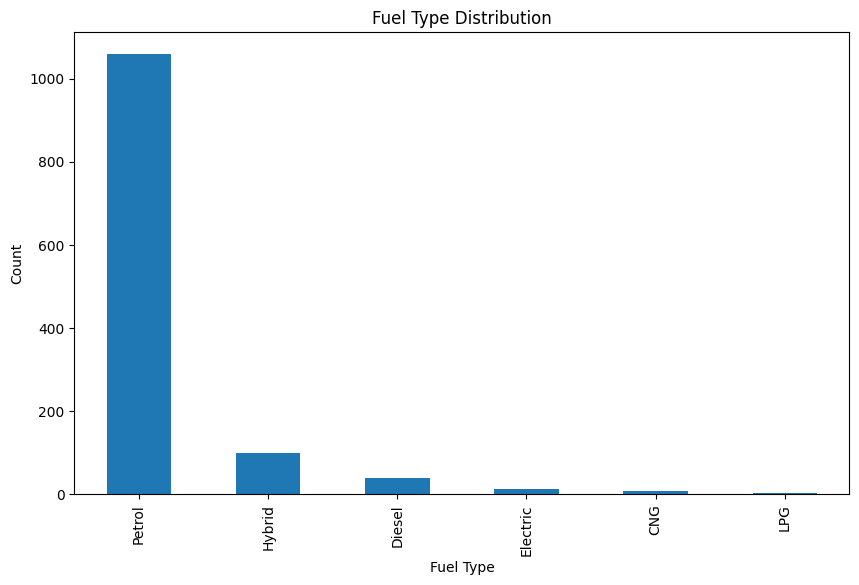

In [76]:
# --------------------------------------------------
# 4) Fuel Type Count (Bar Chart)
# --------------------------------------------------
plt.figure(figsize=(10,6))
df["Fuel Type"].value_counts().plot(kind="bar")
plt.xlabel("Fuel Type")
plt.ylabel("Count")
plt.title("Fuel Type Distribution")
plt.show()

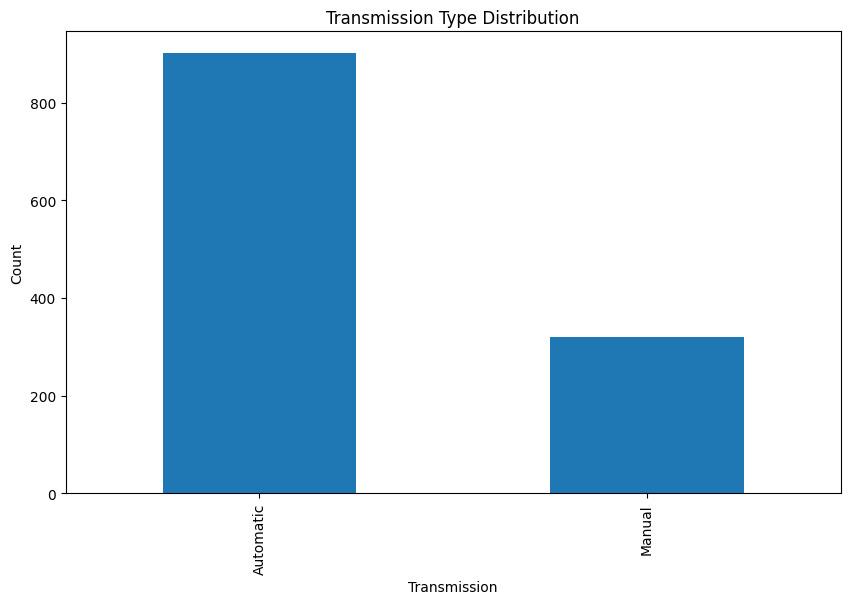

In [77]:
# --------------------------------------------------
# 5) Transmission Count (Bar Chart)
# --------------------------------------------------
plt.figure(figsize=(10,6))
df["Transmission"].value_counts().plot(kind="bar")
plt.xlabel("Transmission")
plt.ylabel("Count")
plt.title("Transmission Type Distribution")
plt.show()

# Brand-Wise Visualization

In [78]:
# -------------------------------
# Extract Brand from Car Name
# -------------------------------
df["Brand"] = df["Car Name"].str.split().str[0]

In [79]:
df

,Car Name,City,Price (PKR),Model Year,Mileage (km),Fuel Type,Engine CC,Transmission,Brand
0,Suzuki Alto VXL AGS,Karachi,3150000.0,2024,27614.0,Petrol,660 cc,Automatic,Suzuki
1,MG HS Trophy,Karachi,5900000.0,2021,21268.0,Petrol,1500 cc,Automatic,MG
2,KIA Sorento 2.4 FWD,Karachi,7450000.0,2021,18727.0,Petrol,2400 cc,Automatic,KIA
3,Mazda Scrum Wagon,Karachi,2900000.0,2020,114000.0,Petrol,660 cc,Automatic,Mazda
4,Daihatsu Mira L,Karachi,2200000.0,2015,140000.0,Petrol,660 cc,Automatic,Daihatsu
...,...,...,...,...,...,...,...,...,...
1217,Toyota Hilux Revo GR Sport,Karachi,16000000.0,2023,100.0,Diesel,2400 cc,Automatic,Toyota
1218,Toyota Prado TZ 4.0,Karachi,16000000.0,2012,79120.0,Petrol,4000 cc,Automatic,Toyota
1219,Toyota Raize Z,Karachi,5875000.0,2020,69000.0,Petrol,1000 cc,Automatic,Toyota
1220,Toyota Corolla Altis Automatic 1.6,Karachi,4500000.0,2017,25251.0,Petrol,1600 cc,Automatic,Toyota


In [80]:
df.dtypes

Car Name         object
City             object
Price (PKR)     float64
Model Year       object
Mileage (km)    float64
Fuel Type        object
Engine CC        object
Transmission     object
Brand            object
dtype: object

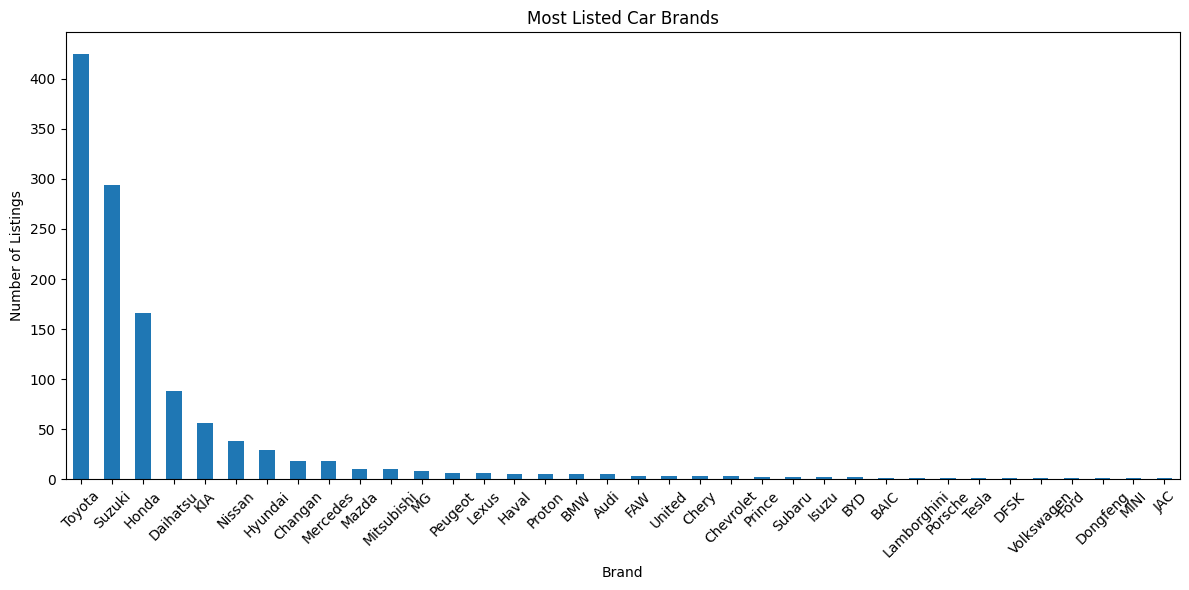

In [91]:
# -------------------------------
# 1) Brand Count
# -------------------------------
plt.figure(figsize=(12,6))
df["Brand"].value_counts().plot(kind="bar")
plt.title("Most Listed Car Brands")
plt.xlabel("Brand")
plt.ylabel("Number of Listings")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [83]:
df["Brand"].value_counts()

Brand
Toyota         425
Suzuki         294
Honda          166
Daihatsu        88
KIA             56
Nissan          38
Hyundai         29
Changan         18
Mercedes        18
Mazda           10
Mitsubishi      10
MG               8
Peugeot          6
Lexus            6
Haval            5
Proton           5
BMW              5
Audi             5
FAW              3
United           3
Chery            3
Chevrolet        3
Prince           2
Subaru           2
Isuzu            2
BYD              2
BAIC             1
Lamborghini      1
Porsche          1
Tesla            1
DFSK             1
Volkswagen       1
Ford             1
Dongfeng         1
MINI             1
JAC              1
Name: count, dtype: int64

In [88]:
len(df["Brand"].value_counts())

36

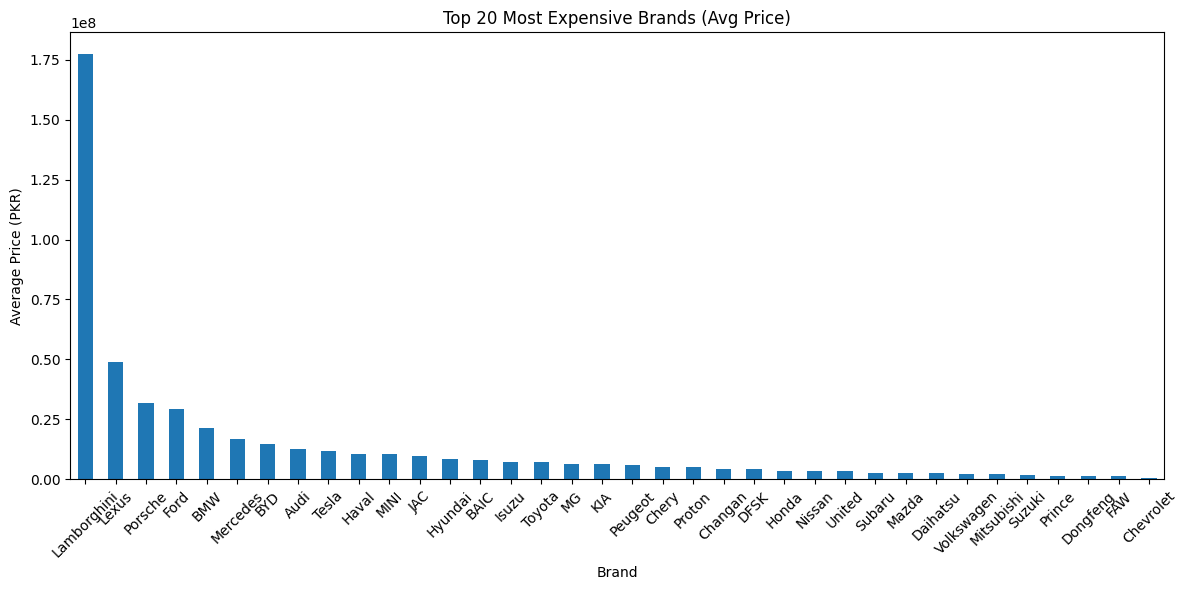

In [86]:
# -------------------------------
# 2) Average Price per Brand
# -------------------------------
plt.figure(figsize=(12,6))
df.groupby("Brand")["Price (PKR)"].mean().sort_values(ascending=False).plot(kind="bar")
plt.title("Top 20 Most Expensive Brands (Avg Price)")
plt.xlabel("Brand")
plt.ylabel("Average Price (PKR)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [87]:
df.groupby("Brand")["Price (PKR)"].mean().sort_values(ascending=False)

Brand
Lamborghini    1.775000e+08
Lexus          4.887500e+07
Porsche        3.200000e+07
Ford           2.950000e+07
BMW            2.140000e+07
Mercedes       1.672083e+07
BYD            1.487500e+07
Audi           1.258000e+07
Tesla          1.200000e+07
Haval          1.066000e+07
MINI           1.050000e+07
JAC            9.900000e+06
Hyundai        8.440345e+06
BAIC           8.100000e+06
Isuzu          7.300000e+06
Toyota         7.096205e+06
MG             6.429375e+06
KIA            6.240982e+06
Peugeot        5.991667e+06
Chery          5.335000e+06
Proton         4.970000e+06
Changan        4.530556e+06
DFSK           4.400000e+06
Honda          3.655982e+06
Nissan         3.614868e+06
United         3.583333e+06
Subaru         2.662500e+06
Mazda          2.628400e+06
Daihatsu       2.613023e+06
Volkswagen     2.095000e+06
Mitsubishi     2.049500e+06
Suzuki         1.889762e+06
Prince         1.387500e+06
Dongfeng       1.300000e+06
FAW            1.216667e+06
Chevrolet     

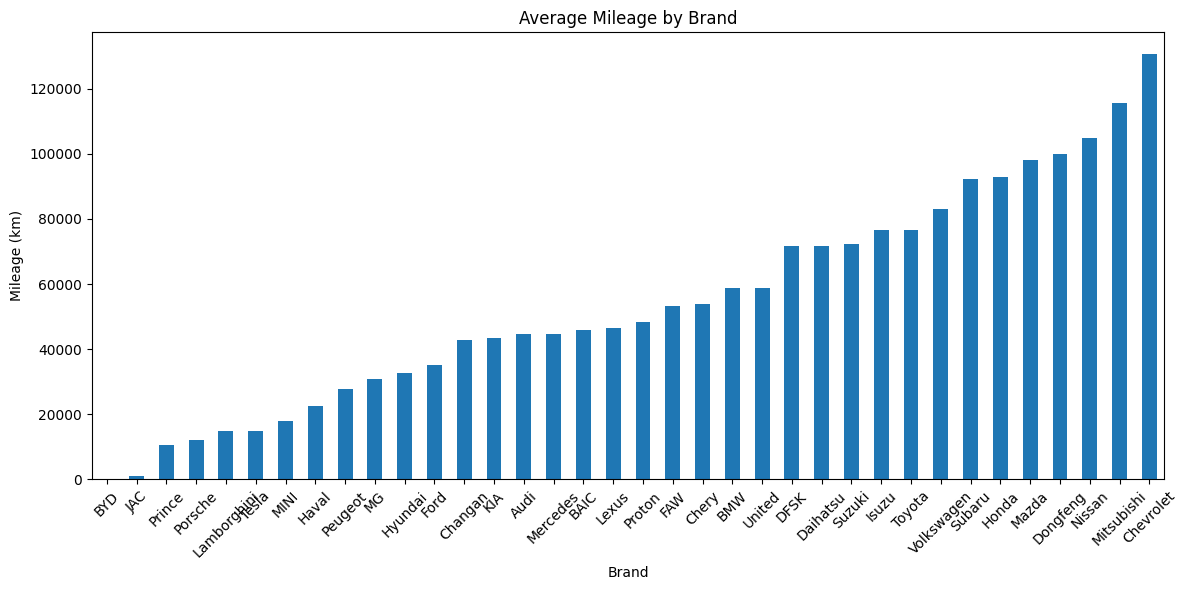

In [90]:
# -------------------------------
# 3) Brand-wise Average Mileage
# -------------------------------
plt.figure(figsize=(12,6))
df.groupby("Brand")["Mileage (km)"].mean().sort_values().plot(kind="bar")
plt.title("Average Mileage by Brand")
plt.xlabel("Brand")
plt.ylabel("Mileage (km)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [92]:
df["Model Year"] = df["Model Year"].astype(int)

In [93]:
df

,Car Name,City,Price (PKR),Model Year,Mileage (km),Fuel Type,Engine CC,Transmission,Brand
0,Suzuki Alto VXL AGS,Karachi,3150000.0,2024,27614.0,Petrol,660 cc,Automatic,Suzuki
1,MG HS Trophy,Karachi,5900000.0,2021,21268.0,Petrol,1500 cc,Automatic,MG
2,KIA Sorento 2.4 FWD,Karachi,7450000.0,2021,18727.0,Petrol,2400 cc,Automatic,KIA
3,Mazda Scrum Wagon,Karachi,2900000.0,2020,114000.0,Petrol,660 cc,Automatic,Mazda
4,Daihatsu Mira L,Karachi,2200000.0,2015,140000.0,Petrol,660 cc,Automatic,Daihatsu
...,...,...,...,...,...,...,...,...,...
1217,Toyota Hilux Revo GR Sport,Karachi,16000000.0,2023,100.0,Diesel,2400 cc,Automatic,Toyota
1218,Toyota Prado TZ 4.0,Karachi,16000000.0,2012,79120.0,Petrol,4000 cc,Automatic,Toyota
1219,Toyota Raize Z,Karachi,5875000.0,2020,69000.0,Petrol,1000 cc,Automatic,Toyota
1220,Toyota Corolla Altis Automatic 1.6,Karachi,4500000.0,2017,25251.0,Petrol,1600 cc,Automatic,Toyota


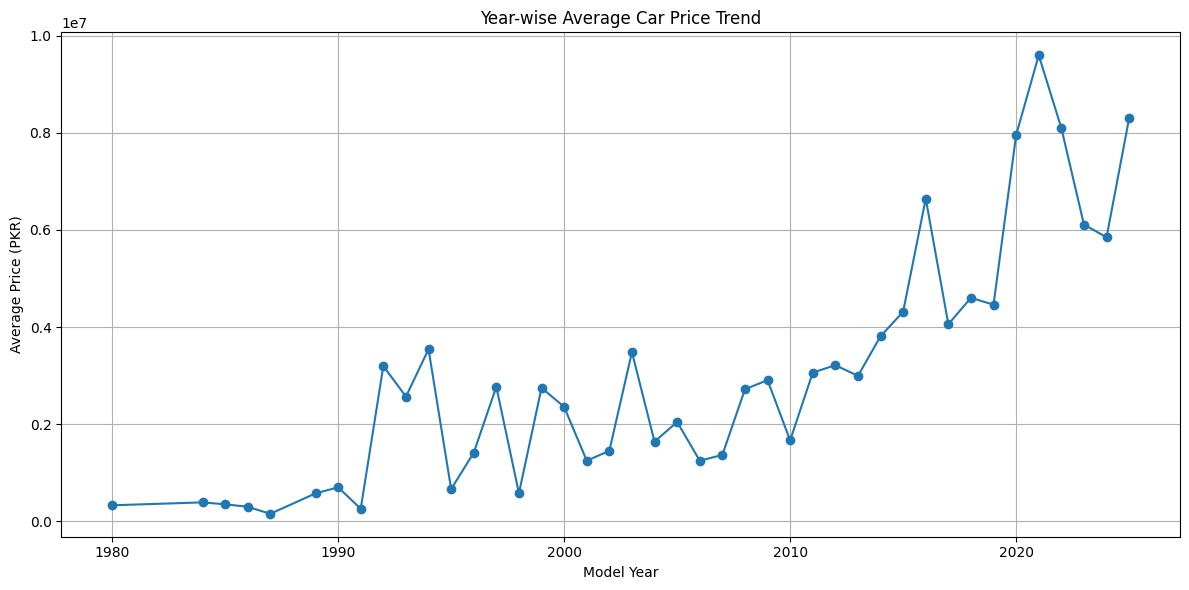

In [94]:
# -------------------------------
# Year-wise Average Price
# -------------------------------
year_price = df.groupby("Model Year")["Price (PKR)"].mean()

plt.figure(figsize=(12,6))
plt.plot(year_price.index, year_price.values, marker="o")
plt.title("Year-wise Average Car Price Trend")
plt.xlabel("Model Year")
plt.ylabel("Average Price (PKR)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [102]:
pip install streamlit

  Using cached streamlit-1.51.0-py3-none-any.whl.metadata (9.5 kB)
  Using cached altair-5.5.0-py3-none-any.whl.metadata (11 kB)
  Using cached blinker-1.9.0-py3-none-any.whl.metadata (1.6 kB)
  Using cached cachetools-6.2.2-py3-none-any.whl.metadata (5.6 kB)
  Using cached click-8.3.1-py3-none-any.whl.metadata (2.6 kB)
  Using cached protobuf-6.33.1-cp310-abi3-win_amd64.whl.metadata (593 bytes)
  Using cached pyarrow-21.0.0.tar.gz (1.1 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached tenacity-9.1.2-py3-none-any.whl.metadata (1.2 kB)
  Using cached toml-0.10.2-py2.py3-none-any.whl.metadata (7.1 kB)
  Using cached watchdog-6.0.0-py3-none-win_amd64.whl.metadata (44 kB)
  Using cached gitpython

  error: subprocess-exited-with-error
  
  exit code: 1
  
  [876 lines of output]
  C:\Users\STARIZ.PK\AppData\Local\Temp\pip-build-env-r3ivaqf5\overlay\Lib\site-packages\setuptools\config\_apply_pyprojecttoml.py:82: SetuptoolsDeprecationWarning: `project.license` as a TOML table is deprecated
  !!
  
          ********************************************************************************
          Please use a simple string containing a SPDX expression for `project.license`. You can also use `project.license-files`. (Both options available on setuptools>=77.0.0).
  
          By 2026-Feb-18, you need to update your project and remove deprecated calls
          or your builds will no longer be supported.
  
          See https://packaging.python.org/en/latest/guides/writing-pyproject-toml/#license for details.
          ********************************************************************************
  
  !!
    corresp(dist, value, root_dir)
  C:\Users\STARIZ.PK\AppData\Local\Temp\p

In [103]:
import streamlit as st

ModuleNotFoundError: No module named 'streamlit'

In [ ]:
import requests 
from bs4 import BeautifulSoup 
import pandas as pd 
import numpy as np 
import time 
all_cars = [] 
headers = {"User-Agent": "Mozilla/5.0"} 
MAX_PAGES = 50 
for page in range(1, MAX_PAGES + 1): 
    print(f"Scraping page {page}...") 
    url = f"https://www.pakwheels.com/used-cars/search/-/ct_karachi/?page={page}" 
    response = requests.get(url, headers=headers) 
    soup = BeautifulSoup(response.text, "html.parser") 
    ads = soup.select("div.well.search-list.ad-container") 
    if len(ads) == 0: 
        print("No more ads found. Stopping...") 
        break 
    for ad in ads: 
        try: 
            car_name = ad.select_one("a.car-name h3").text.strip() 
            city = ad.select_one("ul.search-vehicle-info li").text.strip() 
            price = ad.select_one("div.price-details").text.strip() 
            detail_items = [li.text.strip() for li in ad.select("ul.search-vehicle-info-2 li")] 
            details = " | ".join(detail_items) 
            all_cars.append({ "Car Name": car_name, "City": city, "Details": details, "Price (PKR)": price, }) 
            except: 
                pass 
    time.sleep(1) 
df = pd.DataFrame(all_cars) 
details_split = df["Details"].str.split(r"\s*\|\s*", expand=True).reindex(columns=range(5)).fillna("") 
df[["Model Year", "Mileage (km)", "Fuel Type", "Engine CC", "Transmission"]] = details_split 
df.drop("Details", axis="columns", inplace = True) 
# CLEAN MILEAGE 
df["Mileage (km)"] = ( df["Mileage (km)"] .str.replace(",", "", regex=False) .str.replace(" km", "", regex=False) .replace("", np.nan) .astype(float) ) 
# CLEAN PRICE 
def clean_price(p): 
    if isinstance(p, str): 
        p = p.replace("PKR", "").replace(",", "").strip() 
# Handle "lacs" / "lac" / "crore" 
if "lacs" in p or "lac" in p: 
    num = float(p.split()[0]) 
    return int(num * 100000) 
# convert to PKR 
if "crore" in p: 
    num = float(p.split()[0]) 
    return int(num * 10000000) 
# If numeric PKR 
try: 
    return int(p) 
except: 
    return np.nan 
return np.nan 
df["Price (PKR)"] = df["Price (PKR)"].apply(clean_price) 
df = df.dropna() 
df.drop_duplicates(inplace=True) 
df["Car Name"] = ( df["Car Name"] .str.replace(r"\s*for sale\s*$", "", case=False, regex=True) .str.strip() ) 
df["Car Name"] = ( df["Car Name"] .str.replace(r"\b(19[7-9][0-9]|20[0-2][0-9])\b", "", regex=True) .str.replace(r"\s+", " ", regex=True) 
# fix double spaces .str.strip() ) 
df = df.reset_index(drop=True)

In [50]:
import pyodbc

server = "."  # Local SQL Server
conn = pyodbc.connect(
    'DRIVER={ODBC Driver 18 for SQL Server};'
    f'SERVER={server};'
    'Trusted_Connection=yes;'
    'Encrypt=no;',   # SSL issue fix
    autocommit=True   # <-- Important
)

cursor = conn.cursor()

# Create database if not exists
cursor.execute("IF DB_ID('CarDB') IS NULL CREATE DATABASE CarDB")

cursor.close()
conn.close()
print("Database is ready!")

Database is ready!


In [53]:
pip install sqlalchemy

   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.1 MB ? eta -:--:--
   -------------- ------------------------- 0.8/2.1 MB 2.1 MB/s eta 0:00:01
   ------------------------ --------------- 1.3/2.1 MB 2.8 MB/s eta 0:00:01
   ---------------------------------- ----- 1.8/2.1 MB 2.6 MB/s eta 0:00:01
   ---------------------------------------- 2.1/2.1 MB 2.4 MB/s  0:00:01

   ---------------------------------------- 0/2 [greenlet]
   -------------------- ------------------- 1/2 [sqlalchemy]
   -------------------- ------------------- 1/2 [sqlalchemy]
   -------------------- ------------------- 1/2 [sqlalchemy]
   -------------------- ------------------- 1/2 [sqlalchemy]
   -------------------- ------------------- 1/2 [sqlalchemy]
   -------------------- ------------------- 1/2 [sqlalchemy]
   -------------------- ------------------- 1/2 [sqlalchemy]
   --

In [56]:
from sqlalchemy import create_engine

server = "."         # Local SQL Server
database = "CarDB"
table_name = "PakWheelsKarachi"

# Correct connection string for Windows Auth and Encrypt disabled
conn_str = (
    "mssql+pyodbc://@{server}/{database}"
    "?driver=ODBC+Driver+18+for+SQL+Server"
    "&trusted_connection=yes"
    "&Encrypt=no"
).format(server=server, database=database)

engine = create_engine(conn_str)

In [57]:
# Insert dataframe into SQL Server
df.to_sql(table_name, con=engine, if_exists='replace', index=False)

print("Data successfully inserted into SQL Server!")


Data successfully inserted into SQL Server!


In [58]:
import pandas as pd
from sqlalchemy import create_engine

server = "."         
database = "CarDB"
table_name = "PakWheelsKarachi"

conn_str = (
    "mssql+pyodbc://@{server}/{database}"
    "?driver=ODBC+Driver+18+for+SQL+Server"
    "&trusted_connection=yes"
    "&Encrypt=no"
).format(server=server, database=database)

engine = create_engine(conn_str)

# Table ke top 10 rows read karne ke liye
df_sql = pd.read_sql(f"SELECT TOP 10 * FROM {table_name}", con=engine)
print(df_sql)

                                            Car Name     City  Price (PKR)  \
0                             Daihatsu Mira X SA lll  Karachi    4050000.0   
1                  Honda Civic 11th Generation Oriel  Karachi    7700000.0   
2  Honda City 5th (GM2) Generation 1.3 i-VTEC Pro...  Karachi    3800000.0   
3                                     Daihatsu Hijet  Karachi    1600000.0   
4                                Suzuki Alto VXL AGS  Karachi    2550000.0   
5                                Suzuki Alto VXL AGS  Karachi    2950000.0   
6             Honda City Aspire Prosmatec 1.5 i-VTEC  Karachi    3299000.0   
7                                    Suzuki Alto VXR  Karachi    1170000.0   
8              Toyota Corolla GLi Automatic 1.3 VVTi  Karachi    3350000.0   
9                          Audi A3 1.2 TFSI Standard  Karachi    7800000.0   

  Model Year  Mileage (km) Fuel Type Engine CC Transmission  
0       2023        8500.0    Petrol    660 cc    Automatic  
1       2022     